importing data
-

In [1]:
import pandas as pd

# Load CSVs
categories = pd.read_csv("categories.csv")
customers = pd.read_csv("customers.csv")
order_items = pd.read_csv("order_items.csv")
orders = pd.read_csv("orders.csv")
products = pd.read_csv("products.csv")
returns = pd.read_csv("returns.csv")

# Merge customers with orders
orders_customers = orders.merge(customers, on="customer_id", how="left")

# Merge order_items with products + categories
items_products = order_items.merge(products, on="product_id", how="left")
items_products = items_products.merge(categories, on="category_id", how="left")

# Add returns info at the order_item level
items_products = items_products.merge(returns, on="order_item_id", how="left")

# Combine everything: orders + customers + items + products + categories + returns
full_data = orders_customers.merge(items_products, on="order_id", how="left")

print(full_data.head())
print(full_data.shape)


   order_id  customer_id order_status payment_method              name  \
0         1         4087   In Transit    Net Banking   Aishani Kothari   
1         1         4087   In Transit    Net Banking   Aishani Kothari   
2         2         4807    Delivered            UPI        Kamya Kari   
3         2         4807    Delivered            UPI        Kamya Kari   
4         3         1488     Canceled            UPI  Yasti Brahmbhatt   

                      email signup_date         city      state  \
0    darikakala@example.com  2026-01-25      Jodhpur  Rajasthan   
1    darikakala@example.com  2026-01-25      Jodhpur  Rajasthan   
2  handapraneel@example.net  2026-02-05     Vadodara    Gujarat   
3  handapraneel@example.net  2026-02-05     Vadodara    Gujarat   
4    girindra78@example.net  2026-02-16  Dharmanagar    Tripura   

   order_item_id  ...  quantity  unit_price  product_name category_id  \
0         2241.0  ...       1.0     9498.37      Backpack         4.0   
1     

In [2]:
display(full_data.head())

,order_id,customer_id,order_status,payment_method,name,email,signup_date,city,state,order_item_id,...,quantity,unit_price,product_name,category_id,price,cost_price,category_name,return_id,return_date,refund_amount
0,1,4087,In Transit,Net Banking,Aishani Kothari,darikakala@example.com,2026-01-25,Jodhpur,Rajasthan,2241.0,...,1.0,9498.37,Backpack,4.0,9498.37,8083.69,Home & Kitchen Furniture,NaN,NaN,NaN
1,1,4087,In Transit,Net Banking,Aishani Kothari,darikakala@example.com,2026-01-25,Jodhpur,Rajasthan,12184.0,...,5.0,4390.08,Office chair,1.0,4390.08,3526.10,Apparel/Fashion,NaN,NaN,NaN
2,2,4807,Delivered,UPI,Kamya Kari,handapraneel@example.net,2026-02-05,Vadodara,Gujarat,161.0,...,3.0,3706.59,T-shirt,2.0,3706.59,2428.37,Electronics,NaN,NaN,NaN
3,2,4807,Delivered,UPI,Kamya Kari,handapraneel@example.net,2026-02-05,Vadodara,Gujarat,418.0,...,2.0,41107.70,Backpack,2.0,41107.70,33495.75,Electronics,NaN,NaN,NaN
4,3,1488,Canceled,UPI,Yasti Brahmbhatt,girindra78@example.net,2026-02-16,Dharmanagar,Tripura,5197.0,...,2.0,22730.08,Gaming mouse,1.0,22730.08,18551.58,Apparel/Fashion,NaN,NaN,NaN


**Data Exploration**
-

checking for datatypes
-

In [3]:
print(full_data.dtypes)

order_id            int64
customer_id         int64
order_status       object
payment_method     object
name               object
email              object
signup_date        object
city               object
state              object
order_item_id     float64
product_id        float64
quantity          float64
unit_price        float64
product_name       object
category_id       float64
price             float64
cost_price        float64
category_name      object
return_id         float64
return_date        object
refund_amount     float64
dtype: object


handling missing values
-

In [4]:
# 1. Fill missing IDs and quantities with 0
id_columns = ["order_item_id", "product_id", "quantity", "category_id"]
full_data[id_columns] = full_data[id_columns].fillna(0)

# 2. Convert them to clean integers
full_data[id_columns] = full_data[id_columns].astype("int64")


In [5]:
print(full_data.isnull().sum())


order_id              0
customer_id           0
order_status          0
payment_method        0
name                  0
email                 0
signup_date           0
city                  0
state                 0
order_item_id         0
product_id            0
quantity              0
unit_price         1658
product_name       1658
category_id           0
price              1658
cost_price         1658
category_name      1658
return_id         15158
return_date       15158
refund_amount     15158
dtype: int64


In [6]:
# --- 1. Refund Amounts ---
# Strategy: Fill with 0 (If there is no return, the refund amount is $0)
full_data["refund_amount"] = full_data["refund_amount"].fillna(0.0)

# --- 2. Customer Ratings (If present in your columns) ---
# Strategy: Fill with median or a flag like -1 so it doesn't skew analysis
if "customer_rating" in full_data.columns:
    full_data["customer_rating"] = full_data["customer_rating"].fillna(-1)

# --- 3. Shipment Modes (If present in your columns) ---
# Strategy: Flag as "Unknown" since it is categorical text
if "shipment_mode" in full_data.columns:
    full_data["shipment_mode"] = full_data["shipment_mode"].fillna("Unknown")
    
# --- 4. Return Dates ---
# Strategy: Flag missing text dates as "No Return"
full_data["return_date"] = full_data["return_date"].fillna("No Return")

In [7]:
print(full_data[["refund_amount", "return_date"]].isnull().sum())

refund_amount    0
return_date      0
dtype: int64


Detect Duplicates
-

In [8]:
# Count total duplicate rows across the entire dataset
duplicate_rows_count = full_data.duplicated().sum()
print(f"Total duplicate rows found: {duplicate_rows_count}")

# Remove duplicate rows if any exist, keeping the first occurrence
if duplicate_rows_count > 0:
    full_data = full_data.drop_duplicates()
    print("Duplicate rows successfully removed.")

Total duplicate rows found: 0


In [9]:
# Check if the combination of order_id and order_item_id has duplicates
key_duplicates = full_data.duplicated(subset=["order_id", "order_item_id"]).sum()
print(f"Duplicate primary key combinations found: {key_duplicates}")

# Optional: If duplicates exist in your keys, drop them to protect data integrity
if key_duplicates > 0:
    full_data = full_data.drop_duplicates(subset=["order_id", "order_item_id"], keep="first")
    print("Duplicate primary keys resolved.")

Duplicate primary key combinations found: 0


Explore Basic Statistics
-

In [10]:
# Display summary statistics for all numeric data
print(full_data.describe())

           order_id   customer_id  order_item_id    product_id      quantity  \
count  16658.000000  16658.000000   16658.000000  16658.000000  16658.000000   
mean    4522.121803   2493.504262    6753.962060    136.037640      2.707768   
std     2595.149904   1439.226339    4682.647192     93.765163      1.611878   
min        1.000000      1.000000       0.000000      0.000000      0.000000   
25%     2280.250000   1235.000000    2507.250000     51.000000      1.000000   
50%     4523.500000   2476.000000    6671.500000    135.000000      3.000000   
75%     6786.000000   3733.000000   10835.750000    218.000000      4.000000   
max     9000.000000   5000.000000   15000.000000    300.000000      5.000000   

         unit_price   category_id         price    cost_price    return_id  \
count  15000.000000  16658.000000  15000.000000  15000.000000  1500.000000   
mean   28640.520514      3.318406  28640.520514  21337.350901   750.500000   
std    16119.620547      2.014494  16119.6205

In [11]:
print("\n--- Running Data Anomaly Audit ---")

# Check 1: Negative Prices or Costs
negative_prices = full_data[full_data['price'] < 0].shape[0]
negative_costs = full_data[full_data['cost_price'] < 0].shape[0]
print(f"Rows with negative prices: {negative_prices}")
print(f"Rows with negative cost prices: {negative_costs}")

# Check 2: Negative Refunds
negative_refunds = full_data[full_data['refund_amount'] < 0].shape[0]
print(f"Rows with negative refund amounts: {negative_refunds}")

# Check 3: Extreme Discounts (If you have a discount column)
if 'discount' in full_data.columns:
    # Flagging discounts over 100% or negative discounts
    bad_discounts = full_data[(full_data['discount'] < 0) | (full_data['discount'] > 1.0)].shape[0]
    print(f"Rows with abnormal discounts (negative or >100%): {bad_discounts}")

# Check 4: Quantity anomalies
zero_qty = full_data[full_data['quantity'] <= 0].shape[0]
print(f"Rows with zero or negative quantities ordered: {zero_qty}")


--- Running Data Anomaly Audit ---
Rows with negative prices: 0
Rows with negative cost prices: 0
Rows with negative refund amounts: 0
Rows with zero or negative quantities ordered: 1658


In [12]:
# 1. Remove rows where quantity is 0 or less
full_data = full_data[full_data['quantity'] > 0]

# 2. Re-run the audit check to confirm they are gone
zero_qty_rem = full_data[full_data['quantity'] <= 0].shape[0]
print(f"Remaining rows with zero or negative quantities: {zero_qty_rem}")
print(f"New dataset shape: {full_data.shape}")


Remaining rows with zero or negative quantities: 0
New dataset shape: (15000, 21)


Profile Relationships
-

In [13]:
print("--- Checking Relational Integrity ---")

# 1. Check item-to-order integrity
# Since you merged order_items onto orders, check if any order_id became null
orphaned_orders = full_data['order_id'].isnull().sum()
print(f"Orphaned order items (missing valid order_id): {orphaned_orders}")

# 2. Check product integrity
# If a product_id from order_items didn't exist in the products file, it became 0 (via fillna)
missing_products = (full_data['product_id'] == 0).sum()
print(f"Items with invalid product_id (not found in products table): {missing_products}")

# 3. Check category integrity
# If a category_id didn't match the categories file, it became 0 (via fillna)
missing_categories = (full_data['category_id'] == 0).sum()
print(f"Products with invalid category_id (not found in categories table): {missing_categories}")


--- Checking Relational Integrity ---
Orphaned order items (missing valid order_id): 0
Items with invalid product_id (not found in products table): 0
Products with invalid category_id (not found in categories table): 0


**Data Analysis**
-

In [14]:
# Merge customers with orders
orders_customers = orders.merge(customers, on="customer_id", how="left")

# Merge order_items with products + categories
items_products = order_items.merge(products, on="product_id", how="left")
items_products = items_products.merge(categories, on="category_id", how="left")

# Add returns info at the order_item level
items_products = items_products.merge(returns, on="order_item_id", how="left")

# Combine everything into one master dataset
full_data = orders_customers.merge(items_products, on="order_id", how="left")

# Now full_data exists
print(full_data.head())
print(full_data.shape)

   order_id  customer_id order_status payment_method              name  \
0         1         4087   In Transit    Net Banking   Aishani Kothari   
1         1         4087   In Transit    Net Banking   Aishani Kothari   
2         2         4807    Delivered            UPI        Kamya Kari   
3         2         4807    Delivered            UPI        Kamya Kari   
4         3         1488     Canceled            UPI  Yasti Brahmbhatt   

                      email signup_date         city      state  \
0    darikakala@example.com  2026-01-25      Jodhpur  Rajasthan   
1    darikakala@example.com  2026-01-25      Jodhpur  Rajasthan   
2  handapraneel@example.net  2026-02-05     Vadodara    Gujarat   
3  handapraneel@example.net  2026-02-05     Vadodara    Gujarat   
4    girindra78@example.net  2026-02-16  Dharmanagar    Tripura   

   order_item_id  ...  quantity  unit_price  product_name category_id  \
0         2241.0  ...       1.0     9498.37      Backpack         4.0   
1     

In [15]:
print(full_data[['refund_amount']].describe())
print("Unique customers:", full_data['customer_id'].nunique())
print("Unique orders:", full_data['order_id'].nunique())


       refund_amount
count    1500.000000
mean    85593.041987
std     66791.163834
min       202.650000
25%     32158.877500
50%     70859.360000
75%    128131.390000
max    307518.600000
Unique customers: 4162
Unique orders: 9000


In [16]:
category_sales = full_data.groupby('category_id')['refund_amount'].sum().sort_values(ascending=False)
print(category_sales.head())


category_id
6.0    26156811.33
5.0    25183217.99
1.0    25075259.57
4.0    18048767.90
2.0    17412071.38
Name: refund_amount, dtype: float64


In [17]:
return_rate = full_data['return_id'].notnull().mean()
print("Return Rate:", return_rate)

refund_total = full_data['refund_amount'].sum()
print("Total Refund Amount:", refund_total)


Return Rate: 0.0900468243486613
Total Refund Amount: 128389562.97999999


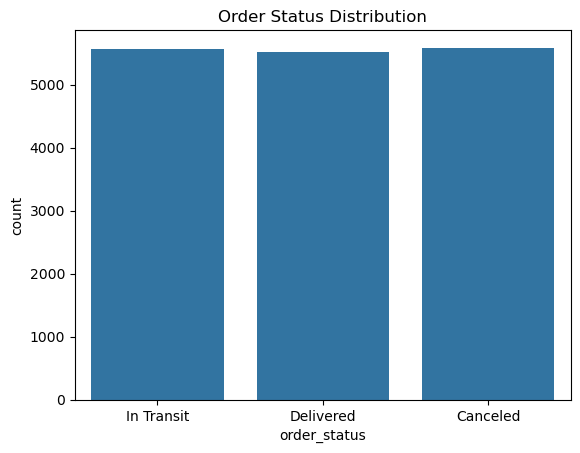

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='order_status', data=full_data)
plt.title("Order Status Distribution")
plt.show()

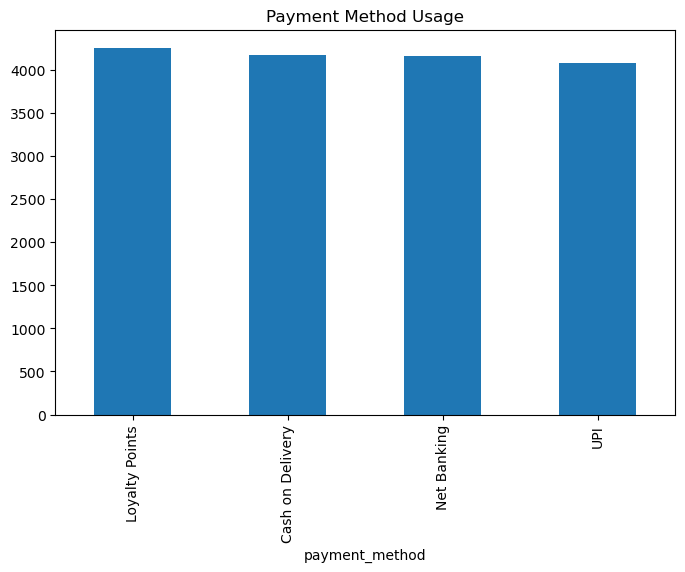

In [19]:
payment_counts = full_data['payment_method'].value_counts()
payment_counts.plot(kind='bar', figsize=(8,5), title="Payment Method Usage")
plt.show()

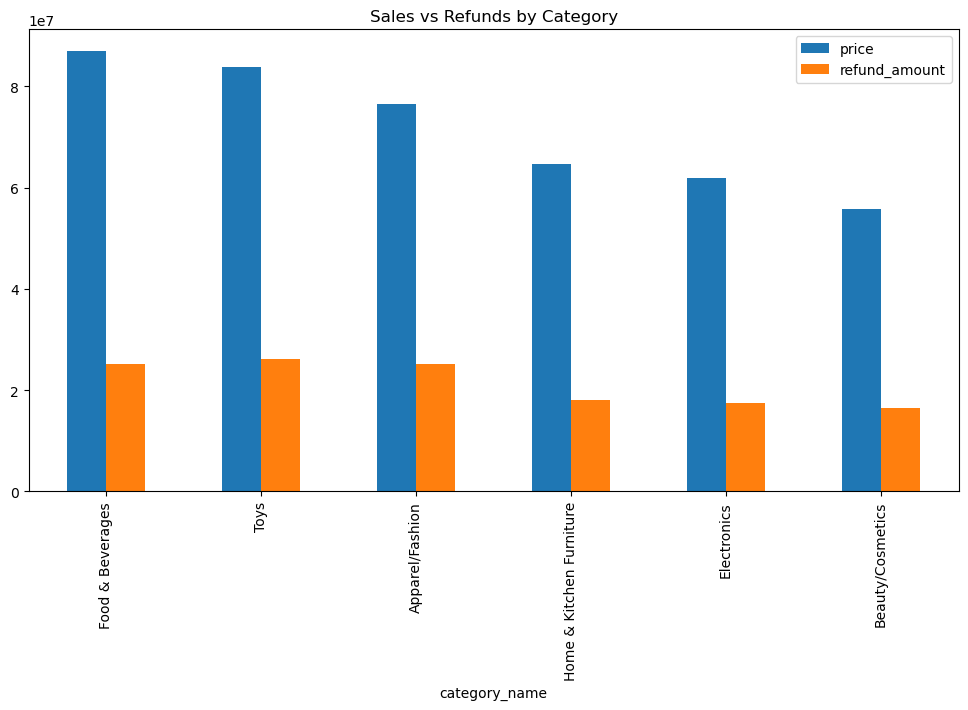

In [20]:
category_perf = full_data.groupby('category_name').agg({
    'price':'sum',
    'refund_amount':'sum'
}).sort_values('price', ascending=False)

category_perf[['price','refund_amount']].plot(kind='bar', figsize=(12,6))
plt.title("Sales vs Refunds by Category")
plt.show()

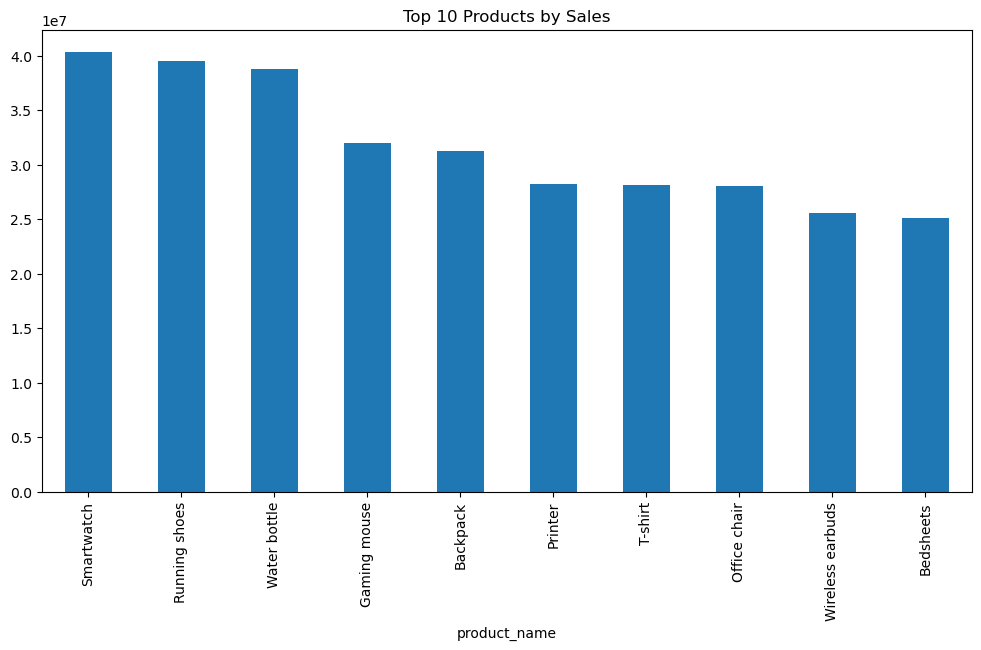

In [21]:
top_products = full_data.groupby('product_name')['price'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='bar', figsize=(12,6), title="Top 10 Products by Sales")
plt.show()

In [ ]:
import urllib.parse
from sqlalchemy import create_engine

# 1. Corrected credentials based on your MySQL Workbench configuration
user = "root"  
password = "mySQL@7786"
host = "localhost"
port = "3342"
database = "ecommerce_db"

# 2. Safely encode the '@' symbol in your password
safe_password = urllib.parse.quote_plus(password)

# 3. Construct the connection string using the variable names
conn_string = (
    f"mysql+mysqlconnector://{user}:{safe_password}@{host}:{port}/{database}"
)

# 4. Create the engine
engine = create_engine(conn_string)

# 5. Run the upload
print("Streaming data to MySQL...")
full_data.to_sql(
    name="fact_sales", con=engine, if_exists="replace", index=False
)
print("Pipeline successful!")

Streaming data to MySQL...
Pipeline successful!
